# 📊 Titanic Survival Analysis  
**Data Science with Python Internship – Task 2**

This notebook is FIXED to work with different Titanic datasets  
(case-insensitive column handling included).

**Tools:** Pandas, Matplotlib, Seaborn  
**Dataset:** Titanic CSV


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
# Load dataset
df = pd.read_csv("titanic.csv")

# FIX: normalize column names
df.columns = df.columns.str.strip().str.lower()

df.head()

,survived,pclass,name,sex,age,fare,sibsp,parch
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,1,0
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,0,0


In [6]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   name      714 non-null    object 
 3   sex       714 non-null    object 
 4   age       714 non-null    float64
 5   fare      714 non-null    float64
 6   sibsp     714 non-null    int64  
 7   parch     714 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 44.8+ KB


In [7]:
# Missing values check
df.isnull().sum()

,0
survived,0
pclass,0
name,0
sex,0
age,0
fare,0
sibsp,0
parch,0


In [8]:
# Data Cleaning
if 'age' in df.columns:
    df['age'].fillna(df['age'].median(), inplace=True)

if 'embarked' in df.columns:
    df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

if 'cabin' in df.columns:
    df.drop('cabin', axis=1, inplace=True)

df.isnull().sum()

/tmp/ipython-input-1928473231.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


,0
survived,0
pclass,0
name,0
sex,0
age,0
fare,0
sibsp,0
parch,0


## Analysis

In [9]:
# Survival rate by gender
df.groupby('sex')['survived'].mean()

,survived
sex,
female,0.754789
male,0.205298


In [10]:
# Survival rate by passenger class
df.groupby('pclass')['survived'].mean()

,survived
pclass,
1,0.655914
2,0.479769
3,0.239437


In [11]:
# Survival rate by age group
bins = [0, 12, 20, 40, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle Age', 'Senior']
df['agegroup'] = pd.cut(df['age'], bins=bins, labels=labels)

df.groupby('agegroup')['survived'].mean()

/tmp/ipython-input-2221813175.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('agegroup')['survived'].mean()


,survived
agegroup,
Child,0.579710
Teen,0.381818
Adult,0.397403
Middle Age,0.390625
Senior,0.227273


## Visualizations

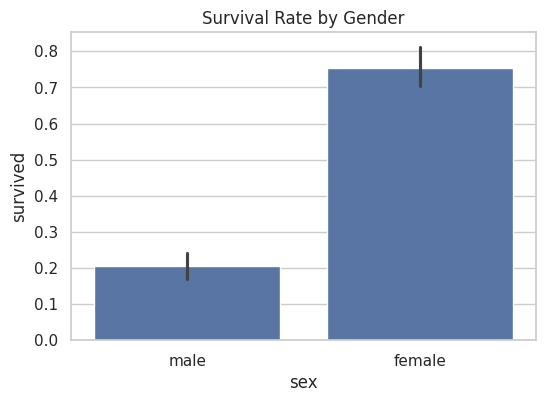

In [12]:
# Survival by Gender
plt.figure(figsize=(6,4))
sns.barplot(x='sex', y='survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

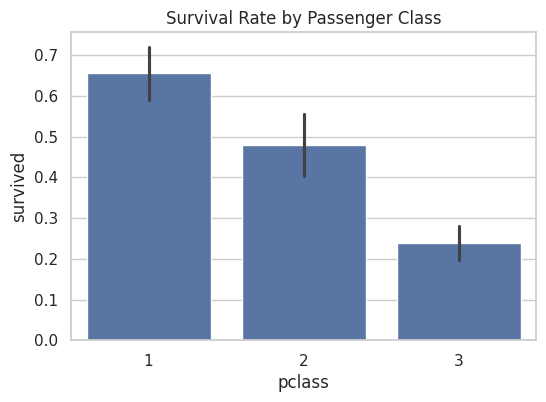

In [13]:
# Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.barplot(x='pclass', y='survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

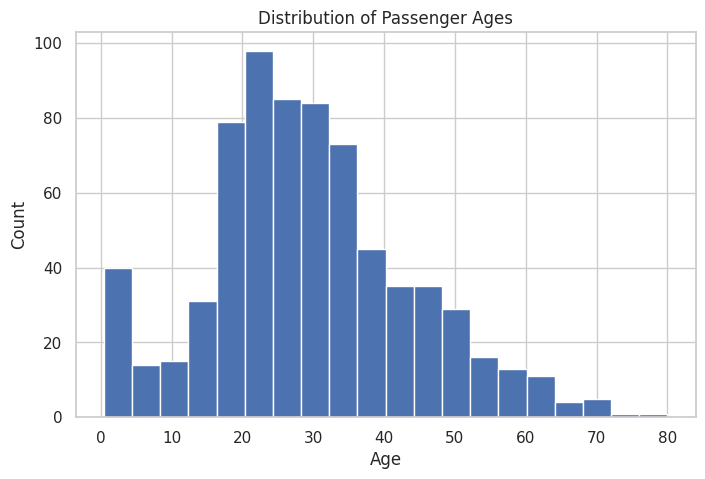

In [14]:
# Age Distribution
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Final Insights

- Females survived more than males.
- First-class passengers had the highest survival rate.
- Children had better survival chances.
- Third-class adults had the lowest survival rate.
